# JEPA Writeup 7/22 results


In [1]:
from pathlib import Path
import json
import os
import subprocess

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd

from cody_jepa.single_stream_jepa import load_checkpoint


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'outputs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the cody-jepa repository root')


REPO_ROOT = find_repo_root()
CHECKPOINT_PATH = REPO_ROOT / 'outputs' / 'jepa-v4' / 'latest.pt'
OUTPUT_DIR = Path(os.environ.get(
    'CODY_JEPA_REPRO_OUTPUT_DIR',
    REPO_ROOT / 'results' / 'generated' / 'writeup-7-22',
)).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(CHECKPOINT_PATH)

print(f'Repository: {REPO_ROOT}')
print(f'Checkpoint: {CHECKPOINT_PATH.relative_to(REPO_ROOT)}')
print(f'Generated artifacts: {OUTPUT_DIR}')


Repository: /Users/theodoremui/dev/cody-jepa
Checkpoint: outputs/jepa-v4/latest.pt
Generated artifacts: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-22


## Load and validate stored values

Training loss and cosine are recorded every epoch. Validation metrics are recorded every five epochs. No values are interpolated or transcribed from the PDF.


In [2]:
checkpoint = load_checkpoint(CHECKPOINT_PATH)
history = checkpoint.get('history')
if not isinstance(history, list) or len(history) != 100:
    raise ValueError('Expected a complete 100-epoch history')
if checkpoint.get('completed_epochs') != 100 or checkpoint.get('global_step') != 3900:
    raise ValueError('Expected the completed epoch-100, step-3900 checkpoint')

rows = []
for item in history:
    validation = item.get('val')
    rows.append({
        'epoch': int(item['epoch']),
        'step': int(item['step']),
        'train_loss': float(item['train_loss']),
        'train_cosine': float(item['train_cosine']),
        'validation_loss': np.nan if validation is None else float(validation['loss']),
        'validation_cosine': np.nan if validation is None else float(validation['cosine']),
        'feature_std': np.nan if validation is None else float(validation['feature_std']),
        'effective_rank': np.nan if validation is None else float(validation['effective_rank']),
        'effective_rank_ratio': np.nan if validation is None else float(validation['effective_rank_ratio']),
        'near_zero_variance_fraction': np.nan if validation is None else float(validation['near_zero_variance_fraction']),
        'wrong_context_gap': np.nan if validation is None else float(validation['subject_balanced_context_shuffle_loss_gap']),
    })

values = pd.DataFrame(rows)
evaluations = values.dropna(subset=['validation_loss']).copy()
if len(evaluations) != 20 or evaluations['epoch'].tolist() != list(range(5, 101, 5)):
    raise ValueError('Expected validation metrics at every fifth epoch')
if not np.isfinite(values[['train_loss', 'train_cosine']].to_numpy()).all():
    raise ValueError('Training history contains non-finite values')
if not np.isfinite(evaluations.drop(columns=['epoch', 'step']).to_numpy()).all():
    raise ValueError('Validation history contains non-finite values')

values_path = OUTPUT_DIR / 'writeup-7-22-plot-values.csv'
values.to_csv(values_path, index=False, float_format='%.17g')
print(f'Validated {len(values)} training rows and {len(evaluations)} validation rows')
print(f'Exact plotted values: {values_path}')


Validated 100 training rows and 20 validation rows
Exact plotted values: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-22/writeup-7-22-plot-values.csv


In [3]:
def read_worktree_or_head(relative_path: str) -> tuple[str, str]:
    path = REPO_ROOT / relative_path
    if path.is_file():
        return path.read_text(encoding='utf-8'), str(path.relative_to(REPO_ROOT))
    result = subprocess.run(
        ['git', 'show', f'HEAD:{relative_path}'],
        cwd=REPO_ROOT, capture_output=True, text=True, check=False,
    )
    if result.returncode == 0:
        return result.stdout, f'HEAD:{relative_path}'
    raise FileNotFoundError(f'{relative_path} is unavailable in the worktree and HEAD')


def require_close(label: str, observed: float, expected: float) -> None:
    if not np.isclose(observed, expected, rtol=1e-10, atol=1e-12):
        raise AssertionError(f'{label}: outputs={observed!r}, report={expected!r}')


report_text, report_source = read_worktree_or_head('reports/phase0-baseline.json')
report = json.loads(report_text)
metric_map = {
    'loss': 'validation_loss',
    'effective_rank': 'effective_rank',
    'effective_rank_ratio': 'effective_rank_ratio',
    'feature_std': 'feature_std',
    'near_zero_variance_fraction': 'near_zero_variance_fraction',
    'subject_balanced_context_shuffle_loss_gap': 'wrong_context_gap',
}
for report_name, epoch in [('best_loss.pt', 80), ('latest.pt', 100)]:
    report_validation = report['candidates'][report_name]['checkpoint']['validation']
    observed = evaluations.loc[evaluations['epoch'].eq(epoch)].iloc[0]
    for report_key, frame_key in metric_map.items():
        require_close(f'{report_name} {report_key}', observed[frame_key], report_validation[report_key])

print(f'All plotted checkpoint metrics match {report_source}')


All plotted checkpoint metrics match HEAD:reports/phase0-baseline.json


## Six-panel result figure


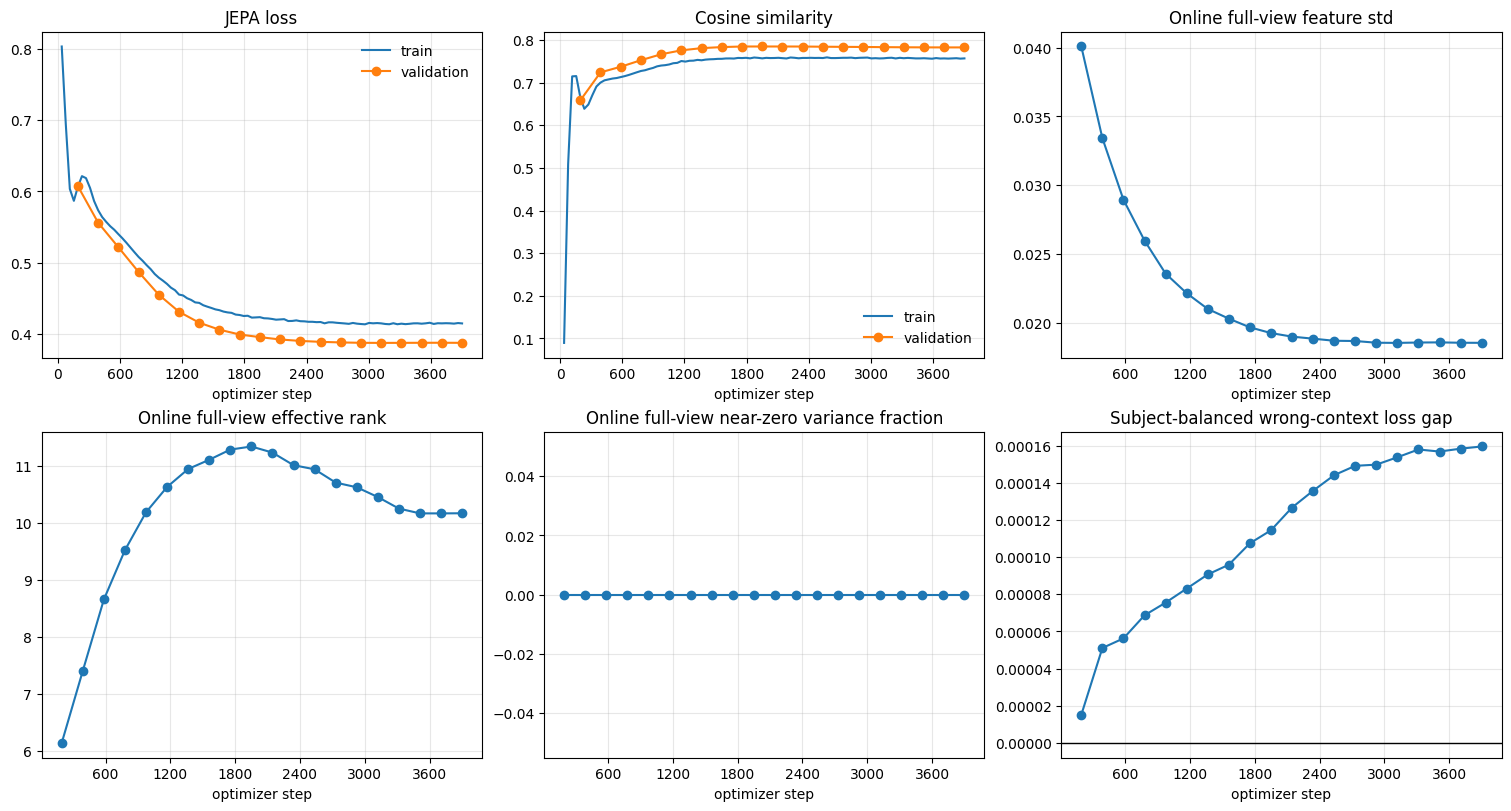

/Users/theodoremui/dev/cody-jepa/results/generated/writeup-7-22/writeup-7-22-health.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].plot(values['step'], values['train_loss'], label='train')
axes[0, 0].plot(evaluations['step'], evaluations['validation_loss'], 'o-', label='validation')
axes[0, 0].set_title('JEPA loss')

axes[0, 1].plot(values['step'], values['train_cosine'], label='train')
axes[0, 1].plot(evaluations['step'], evaluations['validation_cosine'], 'o-', label='validation')
axes[0, 1].set_title('Cosine similarity')

axes[0, 2].plot(evaluations['step'], evaluations['feature_std'], 'o-')
axes[0, 2].set_title('Online full-view feature std')

axes[1, 0].plot(evaluations['step'], evaluations['effective_rank'], 'o-')
axes[1, 0].set_title('Online full-view effective rank')

axes[1, 1].plot(evaluations['step'], evaluations['near_zero_variance_fraction'], 'o-')
axes[1, 1].set_title('Online full-view near-zero variance fraction')

axes[1, 2].plot(evaluations['step'], evaluations['wrong_context_gap'], 'o-')
axes[1, 2].axhline(0, color='black', linewidth=1)
axes[1, 2].set_title('Subject-balanced wrong-context loss gap')

for axis in axes.flat:
    axis.set_xlabel('optimizer step')
    axis.xaxis.set_major_locator(MaxNLocator(8, integer=True))
    axis.grid(True, alpha=0.3)
    if axis.get_legend_handles_labels()[0]:
        axis.legend(frameon=False)

figure_path = OUTPUT_DIR / 'writeup-7-22-health.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()
print(figure_path)


In [5]:
best = evaluations.loc[evaluations['validation_loss'].idxmin()]
final = evaluations.iloc[-1]
headline = pd.DataFrame([
    {'quantity': 'best validation loss', 'epoch': int(best['epoch']), 'value': best['validation_loss']},
    {'quantity': 'final effective rank', 'epoch': int(final['epoch']), 'value': final['effective_rank']},
    {'quantity': 'final effective-rank ratio', 'epoch': int(final['epoch']), 'value': final['effective_rank_ratio']},
    {'quantity': 'final feature std', 'epoch': int(final['epoch']), 'value': final['feature_std']},
    {'quantity': 'final near-zero variance fraction', 'epoch': int(final['epoch']), 'value': final['near_zero_variance_fraction']},
    {'quantity': 'final wrong-context gap', 'epoch': int(final['epoch']), 'value': final['wrong_context_gap']},
])
if int(best['epoch']) != 80:
    raise AssertionError('The stored history no longer has its best validation loss at epoch 80')
print(headline.to_string(index=False))


                         quantity  epoch     value
             best validation loss     80  0.387382
             final effective rank    100 10.167006
       final effective-rank ratio    100  0.026477
                final feature std    100  0.018560
final near-zero variance fraction    100  0.000000
          final wrong-context gap    100  0.000160
